In [2]:
# To import my files
import sys
import os

src = os.path.abspath("./src")

if src not in sys.path:
    sys.path.append(src)

In [3]:
from src.model import DeepONet
from src.dataset import generate_data

In [4]:
u0_tr, xt, y_tr = generate_data(1000, 5, 100, 100, 50, alpha=1.0, T=0.1, seed=0)
u0_te, _,  y_te = generate_data(200,  5, 100, 100, 50, alpha=1.0, T=0.1, seed=1)

In [5]:
import time
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ---- Configuración (nx, nt, T deben coincidir con generate_data) ----
nx, nt, T = 100, 50, 0.1
m, p, hidden = 100, 64, 64
epochs, batch_size, lr = 5000, 100, 1e-3

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ---- Datos al dispositivo ----
u0_tr_d, y_tr_d = u0_tr.to(device), y_tr.to(device)
u0_te_d, y_te_d = u0_te.to(device), y_te.to(device)
xt_d = xt.to(device)

loader = DataLoader(TensorDataset(u0_tr_d, y_tr_d), batch_size=batch_size, shuffle=True)

# ---- Modelo, pérdida, optimizador, scheduler ----
model = DeepONet(m, p, hidden).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
# El lr baja 100x en total a lo largo del entrenamiento
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=(1e-2) ** (1 / epochs))


@torch.no_grad()
def rel_l2(model, u0, xt, y):
    """Error L2 relativo, promediado sobre las funciones."""
    model.eval()
    pred = model(u0, xt)
    err = torch.linalg.norm(pred - y, dim=1) / torch.linalg.norm(y, dim=1)
    return err.mean().item()


# ---- Bucle de entrenamiento ----
history = {"train_loss": [], "test_rel_l2": []}
t0 = time.time()

for epoch in range(1, epochs + 1):
    model.train()
    running, n_batches = 0.0, 0
    for u0_b, y_b in loader:
        optimizer.zero_grad()
        pred = model(u0_b, xt_d)          # (B, Q)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer.step()
        running += loss.item()
        n_batches += 1
    scheduler.step()

    history["train_loss"].append(running / n_batches)
    history["test_rel_l2"].append(rel_l2(model, u0_te_d, xt_d, y_te_d))

    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d} | train MSE {history['train_loss'][-1]:.3e} "
              f"| test rel L2 {history['test_rel_l2'][-1]:.3e} "
              f"| lr {scheduler.get_last_lr()[0]:.2e} | {time.time() - t0:.0f}s")

device: cpu
epoch    1 | train MSE 8.249e+00 | test rel L2 1.968e+00 | lr 9.99e-03 | 0s
epoch   50 | train MSE 2.288e-02 | test rel L2 4.801e-01 | lr 9.55e-03 | 6s
epoch  100 | train MSE 1.666e-02 | test rel L2 4.297e-01 | lr 9.12e-03 | 11s
epoch  150 | train MSE 1.135e-02 | test rel L2 3.360e-01 | lr 8.71e-03 | 16s
epoch  200 | train MSE 7.452e-03 | test rel L2 2.997e-01 | lr 8.32e-03 | 21s
epoch  250 | train MSE 6.549e-03 | test rel L2 2.616e-01 | lr 7.94e-03 | 27s
epoch  300 | train MSE 5.512e-03 | test rel L2 2.398e-01 | lr 7.59e-03 | 32s
epoch  350 | train MSE 4.558e-03 | test rel L2 2.263e-01 | lr 7.24e-03 | 37s
epoch  400 | train MSE 4.924e-03 | test rel L2 2.206e-01 | lr 6.92e-03 | 42s
epoch  450 | train MSE 3.696e-03 | test rel L2 2.053e-01 | lr 6.61e-03 | 47s
epoch  500 | train MSE 1.513e-01 | test rel L2 1.197e+00 | lr 6.31e-03 | 53s
epoch  550 | train MSE 1.446e-01 | test rel L2 1.153e+00 | lr 6.03e-03 | 58s
epoch  600 | train MSE 1.415e-01 | test rel L2 1.176e+00 | lr 5.75

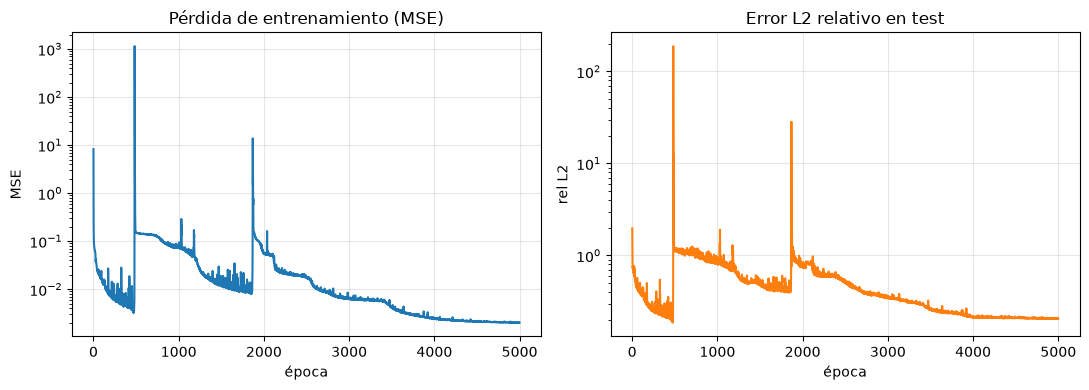

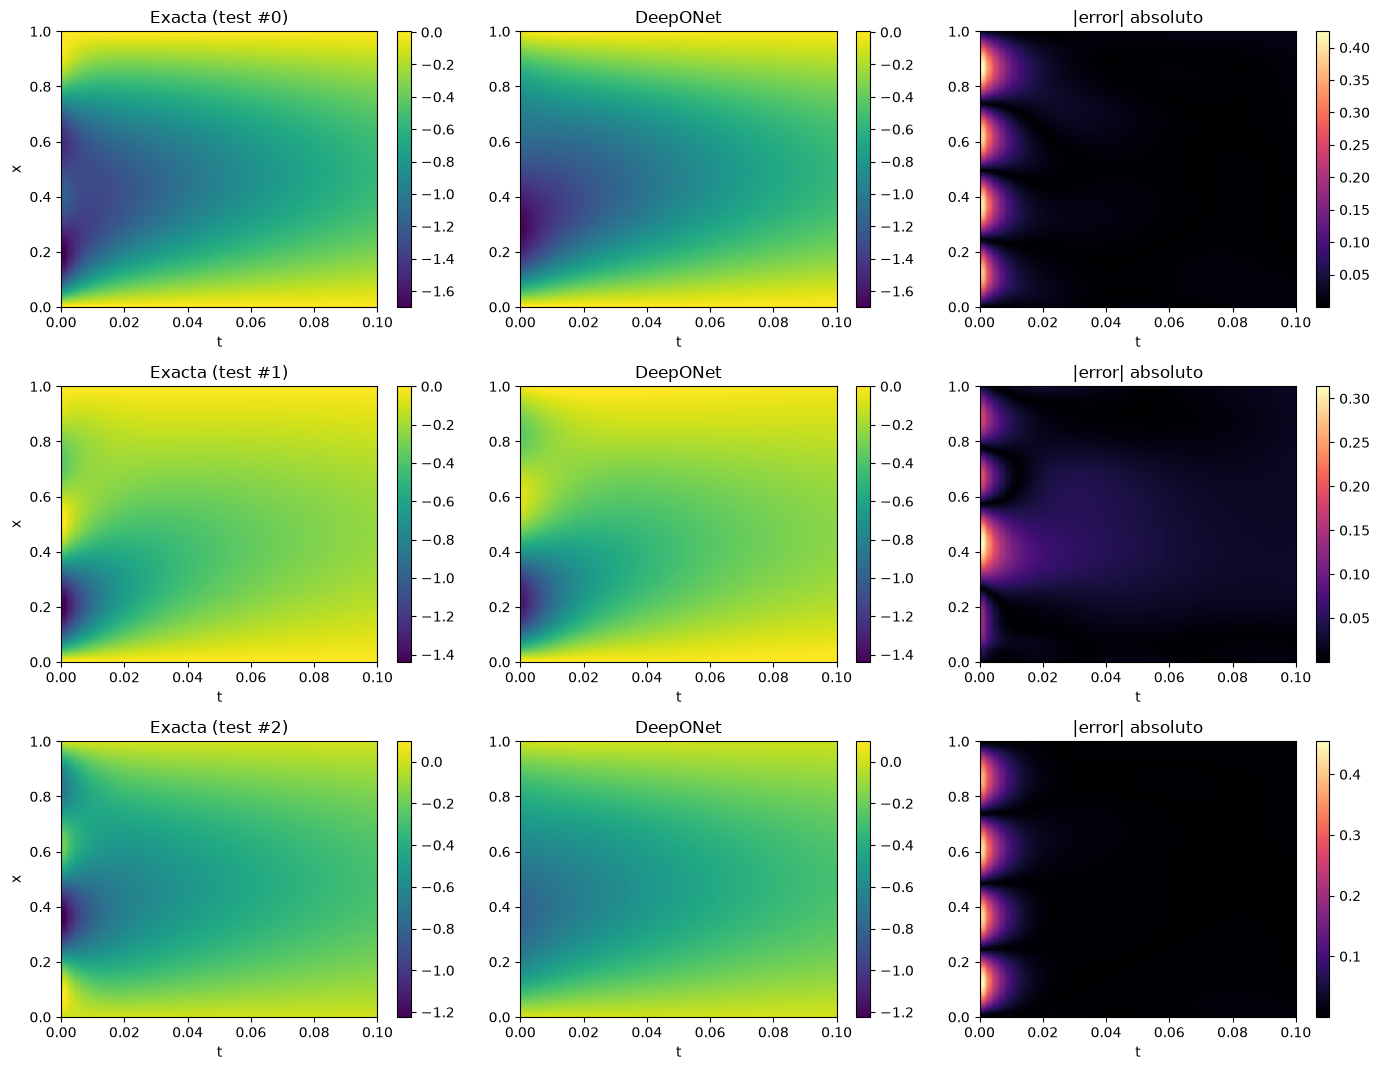

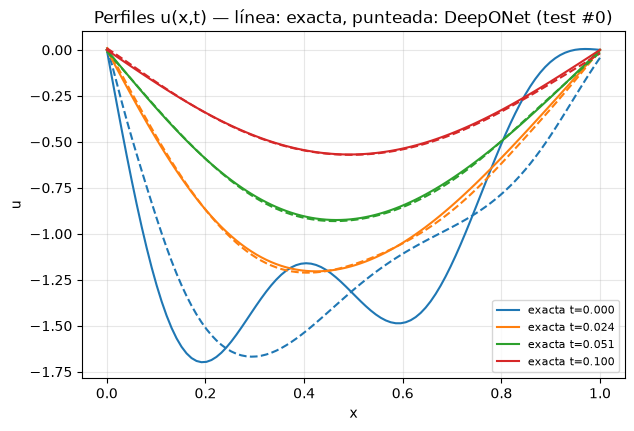

rel L2 test: media 2.063e-01 | mediana 1.164e-01 | peor 3.966e+00


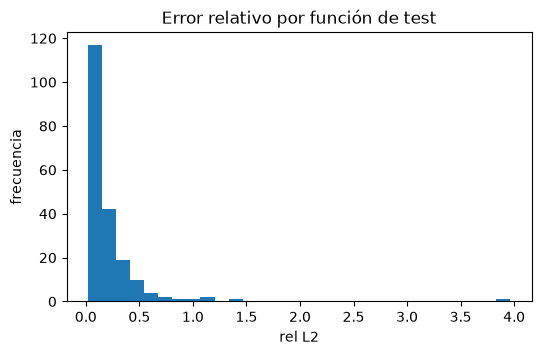

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Curvas de entrenamiento ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(history["train_loss"])
ax[0].set(title="Pérdida de entrenamiento (MSE)", xlabel="época", ylabel="MSE")
ax[1].semilogy(history["test_rel_l2"], color="C1")
ax[1].set(title="Error L2 relativo en test", xlabel="época", ylabel="rel L2")
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- 2. Predicción vs exacta (mapas de calor) para varias funciones de test ----
model.eval()
with torch.no_grad():
    pred_te = model(u0_te_d, xt_d).cpu()

idx = [0, 1, 2]   # funciones de test a mostrar
fig, axes = plt.subplots(len(idx), 3, figsize=(14, 3.6 * len(idx)))

for row, i in enumerate(idx):
    exact = y_te[i].reshape(nx, nt).numpy()      # filas = x, columnas = t
    pred = pred_te[i].reshape(nx, nt).numpy()
    err = np.abs(pred - exact)
    vmin, vmax = exact.min(), exact.max()
    ext = [0, T, 0, 1]

    im0 = axes[row, 0].imshow(exact, origin="lower", aspect="auto", extent=ext, vmin=vmin, vmax=vmax, cmap="viridis")
    im1 = axes[row, 1].imshow(pred, origin="lower", aspect="auto", extent=ext, vmin=vmin, vmax=vmax, cmap="viridis")
    im2 = axes[row, 2].imshow(err, origin="lower", aspect="auto", extent=ext, cmap="magma")

    axes[row, 0].set_title(f"Exacta (test #{i})")
    axes[row, 1].set_title("DeepONet")
    axes[row, 2].set_title("|error| absoluto")
    axes[row, 0].set_ylabel("x")
    for col, im in enumerate([im0, im1, im2]):
        axes[row, col].set_xlabel("t")
        fig.colorbar(im, ax=axes[row, col])

plt.tight_layout()
plt.show()

# ---- 3. Perfiles espaciales a distintos tiempos (una función de test) ----
i = 0
exact = y_te[i].reshape(nx, nt).numpy()
pred = pred_te[i].reshape(nx, nt).numpy()
x_grid = np.linspace(0, 1, nx)

plt.figure(figsize=(7, 4.5))
for c, j in enumerate([0, nt // 4, nt // 2, nt - 1]):
    t_val = j * T / (nt - 1)
    plt.plot(x_grid, exact[:, j], color=f"C{c}", label=f"exacta t={t_val:.3f}")
    plt.plot(x_grid, pred[:, j], "--", color=f"C{c}")
plt.title(f"Perfiles u(x,t) — línea: exacta, punteada: DeepONet (test #{i})")
plt.xlabel("x"); plt.ylabel("u")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.show()

# ---- 4. Distribución del error relativo por función ----
per_fn = (torch.linalg.norm(pred_te - y_te, dim=1) / torch.linalg.norm(y_te, dim=1)).numpy()
print(f"rel L2 test: media {per_fn.mean():.3e} | mediana {np.median(per_fn):.3e} | peor {per_fn.max():.3e}")
plt.figure(figsize=(6, 3.5))
plt.hist(per_fn, bins=30)
plt.title("Error relativo por función de test"); plt.xlabel("rel L2"); plt.ylabel("frecuencia")
plt.show()